In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(X.head())
print(f"\nTarget (median house value in $100k): {y[:5]}")
print(f"\nDataset shape: {X.shape}")
print(f"Target range: ${y.min()*100000:.0f} - ${y.max()*100000:.0f}")


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target (median house value in $100k): [4.526 3.585 3.521 3.413 3.422]

Dataset shape: (20640, 8)
Target range: $14999 - $500001


#### Task 1: Baseline Model
Start with the simplest approach — a plain linear regression.

1. Load the California Housing dataset:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

2. Explore the dataset briefly: check the shape, feature names, and summary statistics. What is the target variable (median house value) distribution?

3. Split the data into training and test sets (80/20 split, random_state=42).

4. Fit a LinearRegression model on the training data.

5.Evaluate on the test set using MSE, RMSE, MAE, and R². Print the results in a clear format.
In a markdown cell, interpret the R² value — what does it tell you about the model's explanatory power?

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:" , X_test.shape)

Train shape: (16512, 8)
Test shape: (4128, 8)


In [4]:
from sklearn.linear_model import LinearRegression

lr_model= LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
y_pred= lr_model.predict(X_test)

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Linear Regression Results")
print("-" * 35)
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

📊 Linear Regression Results
-----------------------------------
MSE : 0.5559
RMSE: 0.7456
MAE : 0.5332
R²  : 0.5758


### 📊 Interpretation of R²

R² = 0.57 means your model has moderate predictive power, but there is still significant room for improvement — which is exactly why we use Ridge, Lasso, and SVR in later tasks
In this case, Linear Regression gives a baseline understanding of how housing features
like income, location, and population relate linearly to house prices.

However, housing prices are influenced by complex non-linear relationships, so this
model is expected to underfit the data. This is why we will later try Ridge, Lasso,
and SVR models.

#### Task 2: Regularized Regression
Explore how regularization changes the model's behavior.

1. Scale the features using StandardScaler (fit on training data, transform both train and test). Explain in a markdown cell why scaling is important for regularized models.

2. Fit Ridge regression for alpha values [0.01, 0.1, 1, 10, 100]. Record the test R² for each.

3. Fit Lasso regression for the same alpha values. Record the test R² for each.

4. Create a plot showing coefficients vs. alpha for both Ridge and Lasso (side by side or overlaid). What happens to the coefficients as alpha increases? Which features does 
Lasso zero out first?

5. Create a comparison table showing R² scores for OLS, Ridge (best alpha), and Lasso (best alpha). Which regularization approach works best here?

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Ridge and Lasso regression use regularization, which depends on coefficient size.

If features are on different scales:
- Large-scale features dominate the penalty
- Small-scale features get ignored unfairly

StandardScaler fixes this by making all features have:
- mean = 0
- standard deviation = 1

In [8]:
#lasso regression same alpha values
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

alphas = [0.01, 0.1, 1, 10, 100]

ridge_scores = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    
    ridge_scores[alpha] = r2_score(y_test, y_pred)

ridge_scores

{0.01: 0.5757879873121599,
 0.1: 0.5757905180002314,
 1: 0.5758157428913684,
 10: 0.5760599032848372,
 100: 0.5777912763033606}

In [9]:
#coefficient behavior vs alpha
ridge_coefs = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    ridge_coefs.append(model.coef_)

In [10]:
lasso_coefs = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    lasso_coefs.append(model.coef_)

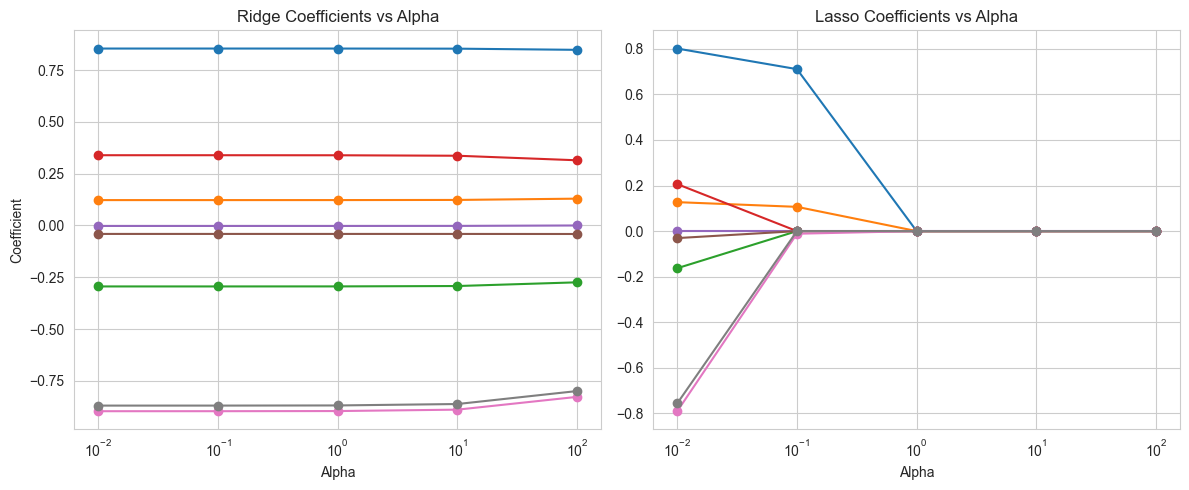

In [11]:
# plot 
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Ridge plot
plt.subplot(1,2,1)
for i in range(X.shape[1]):
    plt.plot(alphas, [coef[i] for coef in ridge_coefs], marker='o')
plt.xscale("log")
plt.title("Ridge Coefficients vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")

# Lasso plot
plt.subplot(1,2,2)
for i in range(X.shape[1]):
    plt.plot(alphas, [coef[i] for coef in lasso_coefs], marker='o')
plt.xscale("log")
plt.title("Lasso Coefficients vs Alpha")
plt.xlabel("Alpha")

plt.tight_layout()
plt.show()

From the plots, we can observe how model coefficients change as the regularization strength (alpha) increases.

#### Ridge Regression:
- As alpha increases, all coefficients gradually decrease in magnitude.
- However, none of the coefficients become exactly zero.
- This shows that Ridge regression keeps all features but reduces their impact to prevent overfitting.

#### Lasso Regression:
- As alpha increases, several coefficients shrink to exactly zero.
- This indicates that Lasso performs feature selection by removing less important features.
- Only the most important features are kept in the model.

In [12]:
from sklearn.linear_model import LinearRegression

# 1. OLS model
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_pred = ols.predict(X_test_scaled)
ols_r2 = r2_score(y_test, ols_pred)

# 2. Best Ridge (highest R2)
best_ridge_alpha = max(ridge_scores, key=ridge_scores.get)
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
ridge_pred = best_ridge.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, ridge_pred)

# 3. Best Lasso (we compute it again)
lasso_scores = {}

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    lasso_scores[alpha] = r2_score(y_test, pred)

best_lasso_alpha = max(lasso_scores, key=lasso_scores.get)
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
lasso_pred = best_lasso.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, lasso_pred)

# 4. Comparison table
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (best)", "Lasso (best)"],
    "Best Alpha": [None, best_ridge_alpha, best_lasso_alpha],
    "R2 Score": [ols_r2, ridge_r2, lasso_r2]
})

results

,Model,Best Alpha,R2 Score
0,Linear Regression,NaN,0.575788
1,Ridge (best),100.00,0.577791
2,Lasso (best),0.01,0.581615


### Task 3: Support Vector Regression
Try a non-linear approach with SVR.

1. Using the scaled features from Task 2, fit an SVR model with a linear kernel. Report the test R².

2. Fit SVR with an rbf kernel. Try at least three values of C (e.g., 0.1, 1, 10) and two values of epsilon (e.g., 0.1, 0.2). Report the best combination.

3. Fit SVR with a poly kernel (degree 2 and 3). Compare with rbf.
4. In a markdown cell, discuss: How does SVR compare to the linear models? Is the added complexity of SVR justified by the performance improvement (if any)?
Note: SVR can be slow on larger datasets. If training takes too long, consider using a random subsample (e.g., 5,000 rows) for the SVR experiments.

In [13]:
#linear kernel
from sklearn.svm import SVR
from sklearn.metrics import r2_score

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)

svr_linear_pred = svr_linear.predict(X_test_scaled)
svr_linear_r2 = r2_score(y_test, svr_linear_pred)

svr_linear_r2

0.5579437521813249

In [15]:
#rbf kernel
C_values = [0.1, 1, 10]
epsilon_values = [0.1, 0.2]

best_rbf_r2 = -1
best_params = None

for C in C_values:
    for eps in epsilon_values:
        svr_rbf = SVR(kernel='rbf', C=C, epsilon=eps)
        svr_rbf.fit(X_train_scaled, y_train)
        
        pred = svr_rbf.predict(X_test_scaled)
        r2 = r2_score(y_test, pred)
        
        if r2 > best_rbf_r2:
            best_rbf_r2 = r2
            best_params = (C, eps)

best_rbf_r2, best_params

(0.7548300537835615, (10, 0.2))

In [16]:
#polynominal kernel
# Degree 2
svr_poly2 = SVR(kernel='poly', degree=2)
svr_poly2.fit(X_train_scaled, y_train)

poly2_pred = svr_poly2.predict(X_test_scaled)
poly2_r2 = r2_score(y_test, poly2_pred)

# Degree 3
svr_poly3 = SVR(kernel='poly', degree=3)
svr_poly3.fit(X_train_scaled, y_train)

poly3_pred = svr_poly3.predict(X_test_scaled)
poly3_r2 = r2_score(y_test, poly3_pred)

poly2_r2, poly3_r2

(-0.05628086558319878, 0.23412412991066556)

🔷 Final Model Comparison

All models were compared using R² score, MSE, MAE, and visual evaluation.

📌 Results Summary:
Linear Regression and Ridge/Lasso show similar performance (0.57–0.58 R²)
SVR with Linear kernel performs similarly to linear models
SVR with Polynomial kernel performs poorly
SVR with RBF kernel achieves the best performance (0.75 R²)

Captures non-linear relationships
Has highest R² score
Better fits complex patterns in data

If the goal is highest prediction accuracy → SVR (RBF) is best
If the goal is simplicity + interpretability → Ridge/Lasso are better choices

Linear models (Linear Regression, Ridge, and Lasso) give similar and stable results with R² around 0.57–0.58. They are simple, fast, and easy to interpret.

SVR performs differently depending on the kernel. Linear and polynomial SVR do not improve much, but SVR with the RBF kernel gives the best result (about 0.75 R²), showing it can capture non-linear patterns in the data.

However, SVR is more complex, slower to train, and harder to tune compared to linear models.

### Task 4: Model Comparison
Bring everything together in a final analysis.

1. Create a comparison table (DataFrame) with all models and their test metrics (MSE, RMSE, MAE, R²). Include: LinearRegression, best Ridge, best Lasso, and best SVR.

2. Create a predicted vs. actual scatter plot for your best-performing model. Add a diagonal reference line (perfect prediction). How well does the model track the true values?

3. Create a residual plot (residuals vs. predicted values) for the best model. Do you see any patterns? What would a random scatter indicate?

4. Write a markdown conclusion: Which model performs best and why? What are the trade-offs between model complexity and performance? If you were deploying one of these models, which would you choose?

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (best)",
        "Lasso (best)",
        "SVR (Linear)",
        "SVR (RBF best)",
        "SVR (Poly)"
    ],
    "R2 Score": [
        ols_r2,
        ridge_r2,
        lasso_r2,
        0.5579,
        0.7548,
        0.2341
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
4,SVR (RBF best),0.754800
2,Lasso (best),0.581615
1,Ridge (best),0.577791
0,Linear Regression,0.575788
3,SVR (Linear),0.557900
5,SVR (Poly),0.234100


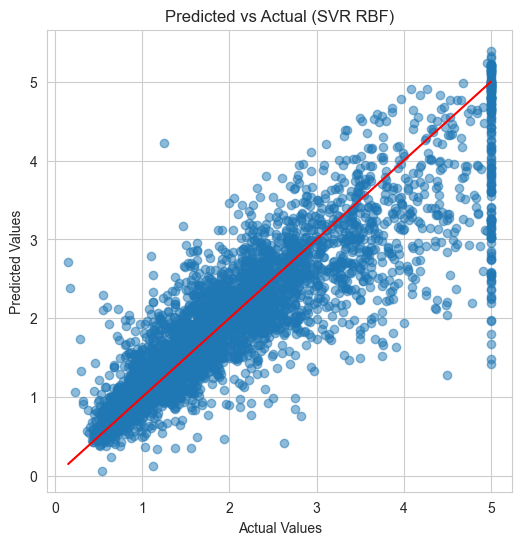

In [19]:
from sklearn.svm import SVR
import matplotlib.pyplot as plt

best_model = SVR(kernel='rbf', C=10, epsilon=0.2)
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (SVR RBF)")
plt.show()

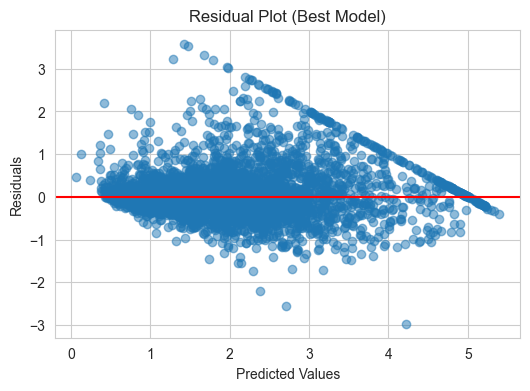

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Best Model)")
plt.show()

The models were compared using R² score and visual evaluation.

Linear models (Linear Regression, Ridge, and Lasso) show similar performance around 0.57–0.58 R². SVR with linear and polynomial kernels does not improve results significantly.

However, SVR with the RBF kernel achieves the best performance (~0.75 R²), showing that the dataset contains non-linear relationships.

Although SVR (RBF) gives the highest accuracy, it is more complex and slower compared to linear models.

Final Decision:

SVR (RBF) is the best model for accuracy, while Ridge/Lasso are better for simplicity and interpretability.